<a href="https://colab.research.google.com/github/susu-xxx/MyStudy/blob/DeepLearning/ex03_1)_%EA%B0%95%EC%95%84%EC%A7%80_%EA%B3%A0%EC%96%91%EC%9D%B4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%A0%84%EC%B2%98%EB%A6%AC_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


### 목표
- 강아지 고양이 이미지를 배열로 변환하는 작업을 진행 (이미지 데이터 전처리)
  - 압축된 형식의 배열로 저장 : npz(Numpy 라이브러리에서 읽고 쓸 수 있는 바이너리 파일)
  - 대용량 데이터를 압축 형태로 정리해두면 클라우드환경에 쉽게 업로드, 다운로드 가능(관리가 편함)
  - 저장 공간 적게 차지



In [3]:
# 1. 압축 폴더 해제
# 2. 이미지 한 장씩 접근
# 3. 이미지 크기 조정
# 4. 배열 변환
# 5. 모든 이미지를 npz 형식으로 저장

In [4]:
# 필요한 라이브러리들 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zipfile import ZipFile

from PIL import Image
import os

In [5]:
zip_file_path = './data/cats_and_dogs_filtered.zip'

with ZipFile(zip_file_path, 'r') as f: #사용할 파일 ('r' 읽기 모드)로 열기
  # path에 있는 압축파일을 해제 후 폴더를 저장할 경로 설정
  f.extractall(path='./data')

  # 결론 = 압축해제

In [6]:
# train -cats, dogs
# test  -cats, dog

In [7]:
# 총 4개의 폴더 경로를 변수에 저장
train_cats_dir = './data/cats_and_dogs_filtered/train/cats'
train_dogs_dir = './data/cats_and_dogs_filtered/train/dogs'

test_cats_dir = './data/cats_and_dogs_filtered/test/cats'
test_dogs_dir = './data/cats_and_dogs_filtered/test/dogs'

# 각 폴더에 있는 이미지의 파일명 접근
#os.listdir

train_cats_fn = os.listdir(train_cats_dir)
train_dogs_fn = os.listdir(train_dogs_dir)

test_cats_fn = os.listdir(test_cats_dir)
test_dogs_fn = os.listdir(test_dogs_dir)

#각각의 이미지 파일 몇 개 들어있는지 개수 확인
print(len(train_cats_fn), len(train_dogs_fn))
print(len(test_cats_fn), len(test_dogs_fn))

1000 1000
500 500


array([[[ 39,  44,  40],
        [ 39,  44,  41],
        [ 41,  45,  44],
        ...,
        [210, 206, 180],
        [204, 201, 168],
        [200, 197, 162]],

       [[ 40,  45,  41],
        [ 40,  44,  42],
        [ 41,  45,  44],
        ...,
        [204, 200, 174],
        [200, 197, 166],
        [197, 194, 160]],

       [[ 39,  44,  40],
        [ 39,  43,  41],
        [ 38,  42,  42],
        ...,
        [198, 193, 168],
        [199, 195, 165],
        [202, 197, 166]],

       ...,

       [[ 30,  28,  29],
        [ 27,  25,  26],
        [ 23,  21,  22],
        ...,
        [ 42,  29,  23],
        [ 38,  26,  20],
        [ 49,  38,  32]],

       [[ 32,  30,  31],
        [ 28,  26,  27],
        [ 23,  21,  22],
        ...,
        [ 38,  24,  18],
        [ 41,  29,  22],
        [ 53,  43,  35]],

       [[ 31,  29,  30],
        [ 27,  25,  26],
        [ 22,  20,  21],
        ...,
        [ 55,  41,  33],
        [ 46,  35,  26],
        [ 42,  33,  23]]], dtype=uint8)
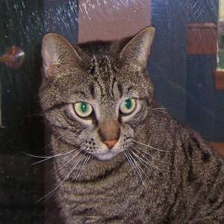

In [8]:
# 이미짖 1장 크기 조정 후 arr 변환
# train_cat 이미지 1장
# train_cats_fn[0]
tmp_path = os.path.join(train_cats_dir, train_cats_fn[0])
# tmp_path = train_cats_dir + '/' + train_cats_fn[0], 위와 동일

img = Image.open(tmp_path).resize((224, 224))
np.array(img)


In [9]:
from tqdm.auto import tqdm

In [10]:
#전처리해주는함수 생성
#사진을 불러와서 배열로 바꾸즌 하수
# 폴더명, 각 파일명 변수, 이미지 사이즈 = 224*224
def prepro_imgs(folder_path, file_names, img_size = (224,224)) :
  imgs = [] # 1장씩 변환해서 append

  #각 이미지 접근해서 불러오기 -> 크기 조정 -> arr -_> 리스트에 담아줌
  for i in tqdm(file_names) : #고양이나 강아지 파일 이름들

    path = os.path.join(folder_path,i)
    #해당 경로 이미지지 불러옴 -> 크기 조정
    img = Image.open(path).resize(img_size)

    #array 변환
    imgs.append(np.array(img))
  return np.array(imgs)

In [11]:
#정의한 함수  사용

#train-cats
x_train_cats = prepro_imgs(train_cats_dir, train_cats_fn)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [12]:
# 나머지 폴더 이미지 변환해보기
x_train_dogs = prepro_imgs(train_dogs_dir, train_dogs_fn)
x_test_cats = prepro_imgs(test_cats_dir, test_cats_fn)
x_test_dogs = prepro_imgs(test_dogs_dir, test_dogs_fn)

#크기 확인
print('훈련셋 : ', x_train_cats.shape, x_train_dogs.shape)
print('테스트셋 : ', x_test_cats.shape, x_test_dogs.shape)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

훈련셋 :  (1000, 224, 224, 3) (1000, 224, 224, 3)
테스트셋 :  (500, 224, 224, 3) (500, 224, 224, 3)


In [13]:
# 두 개의 배열을 병합하는 함수
a = np.array([[1,2], [3,4]])
b = np.array([[5,6], [7,8]])

np.concatenate((a,b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6],
       [7, 8]])

In [14]:
# train cats, dogs 병합
x_train = np.concatenate((x_train_cats, x_train_dogs), axis=0)
x_test = np.concatenate((x_test_cats, x_test_dogs), axis=0)

# 크기 확인
print(x_train.shape, x_test.shape)

(2000, 224, 224, 3) (1000, 224, 224, 3)


In [15]:
# 정답 데이터 생성
#numpy 1차원 배열로 생성
#cat 0, dog 1

y_train = np.array([0]*1000 + [1]*1000)
y_test = np.array([0]*500 + [1]*500)

print(y_train.shape, y_test.shape)

(2000,) (1000,)


In [16]:
# 데이터 세팅 완료 -> npz
# 여러 개의 파일을 압축하여 하나의 .npz파일로 저장하는 함수
np.savez('./data/np_cats_and_dogs.npz',
          x_train=x_train,
         x_test=x_test,
         y_train=y_train,
         y_test=y_test)

In [17]:
# 3-2에서 계속